<h1>DATA PREPROCESSING AND FEATURE ENGINEERING IN MACHINE LEARNING</h1>

In [1]:
import pandas as pd
import numpy as np

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("adult_with_headers (1).csv")
df

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K



#  Basic Data Exploration


In [3]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
df.shape

(32561, 15)

In [5]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [7]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [8]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [9]:
# Numerical columns
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
print("numerical_cols : ",numerical_cols)

# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("categorical_cols : ",categorical_cols)

numerical_cols :  Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')
categorical_cols :  Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')


In [10]:
# Numerical columns
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical columns
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\komal\AppData\Local\Temp\ipykernel_5756\478776598.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\komal\AppData\Local\Temp\ipykernel_5756\478776598.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

In [11]:
# Numerical columns
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [12]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

Missing values were handled using:
- Median imputation for numerical columns
- Mode imputation for categorical columns

This method is preferred because:
- Median is robust to outliers
- Mode preserves most frequent category

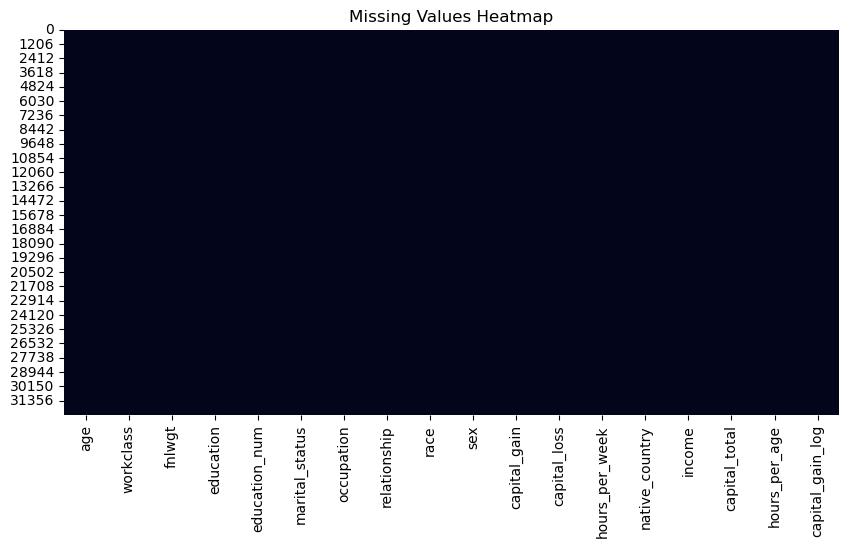

In [58]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


#  Standard Scaling

●	Apply scaling techniques to numerical features:
            a.	Standard Scaling   b. Min-Max Scaling

In [26]:
# Import Libraries
from sklearn.preprocessing import StandardScaler
# Initialize scaler
standard_scaler = StandardScaler()
# Create copy for standard scaling
df_standard_scaled = df.copy()
# Apply scaling
df_standard_scaled[numerical_cols] = standard_scaler.fit_transform(
    df_standard_scaled[numerical_cols]
)
df_standard_scaled.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,capital_total,hours_per_age,capital_gain_log
0,0.030671,7,-1.063611,9,1.134739,4,1,1,4,Male,0.148453,-0.21666,-0.035429,39,<=50K,2174,1.025641,7.684784
1,0.837109,6,-1.008707,9,1.134739,2,4,0,4,Male,-0.145920,-0.21666,-2.222153,39,<=50K,0,0.260000,0.000000
2,-0.042642,4,0.245079,11,-0.420060,0,6,1,4,Male,-0.145920,-0.21666,-0.035429,39,<=50K,0,1.052632,0.000000
3,1.057047,4,0.425801,1,-1.197459,2,6,0,2,Male,-0.145920,-0.21666,-0.035429,39,<=50K,0,0.754717,0.000000
4,-0.775768,4,1.408176,9,1.134739,2,10,5,2,Female,-0.145920,-0.21666,-0.035429,5,<=50K,0,1.428571,0.000000


In [27]:
# Import Libraries
from sklearn.preprocessing import MinMaxScaler
# Initialize scaler
minmax_scaler = MinMaxScaler()
# Create copy for min-max scaling
df_minmax_scaled = df.copy()
# Apply scaling
df_minmax_scaled[numerical_cols] = minmax_scaler.fit_transform(
    df_minmax_scaled[numerical_cols])

df_minmax_scaled.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,capital_total,hours_per_age,capital_gain_log
0,0.301370,7,0.044302,9,0.800000,4,1,1,4,Male,0.02174,0.0,0.397959,39,<=50K,2174,1.025641,7.684784
1,0.452055,6,0.048238,9,0.800000,2,4,0,4,Male,0.00000,0.0,0.122449,39,<=50K,0,0.260000,0.000000
2,0.287671,4,0.138113,11,0.533333,0,6,1,4,Male,0.00000,0.0,0.397959,39,<=50K,0,1.052632,0.000000
3,0.493151,4,0.151068,1,0.400000,2,6,0,2,Male,0.00000,0.0,0.397959,39,<=50K,0,0.754717,0.000000
4,0.150685,4,0.221488,9,0.800000,2,10,5,2,Female,0.00000,0.0,0.397959,5,<=50K,0,1.428571,0.000000


Scaling Comparison

In [59]:
comparison = pd.DataFrame({
    'Original Age': df['age'].head(),
    'Standard Scaled': df_standard_scaled['age'].head(),
    'MinMax Scaled': df_minmax_scaled['age'].head()
})

print(comparison)

   Original Age  Standard Scaled  MinMax Scaled
0            39         0.030671       0.301370
1            50         0.837109       0.452055
2            38        -0.042642       0.287671
3            53         1.057047       0.493151
4            28        -0.775768       0.150685


Boxplots Before and After Scaling 

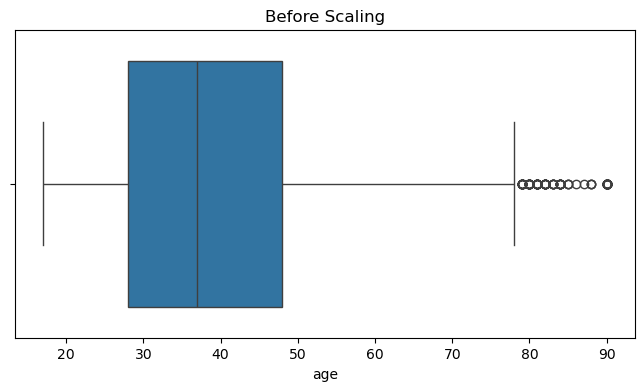

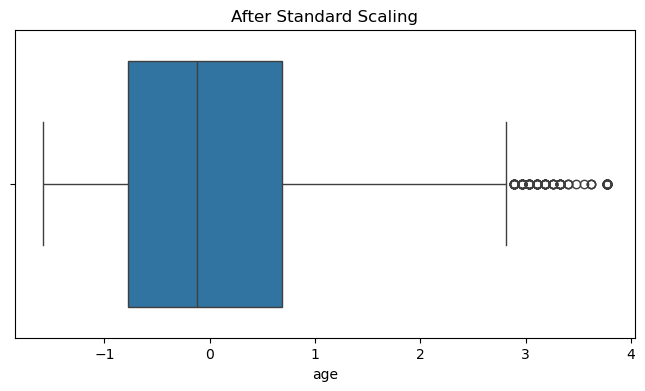

In [60]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['age'])
plt.title("Before Scaling")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=df_standard_scaled['age'])
plt.title("After Standard Scaling")
plt.show()

●	Discuss the scenarios where each scaling technique is preferred and why.

#  One-Hot Encoding
# For columns with less than 5 categories

In [29]:
#One-Hot Encoding
onehot_cols = [col for col in categorical_cols
                  if df[col].nunique() < 5]

print("\nColumns for One-Hot Encoding :",onehot_cols)


Columns for One-Hot Encoding : ['sex', 'income']


In [46]:
# Apply One-Hot Encoding
df_onehot = pd.get_dummies(df , columns = onehot_cols)

df_onehot.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,capital_total,hours_per_age,capital_gain_log,sex_ Female,sex_ Male,income_ <=50K,income_ >50K
0,39,7,77516,9,13,4,1,1,4,2174,0,40,39,2174,1.025641,7.684784,False,True,True,False
1,50,6,83311,9,13,2,4,0,4,0,0,13,39,0,0.260000,0.000000,False,True,True,False
2,38,4,215646,11,9,0,6,1,4,0,0,40,39,0,1.052632,0.000000,False,True,True,False
3,53,4,234721,1,7,2,6,0,2,0,0,40,39,0,0.754717,0.000000,False,True,True,False
4,28,4,338409,9,13,2,10,5,2,0,0,40,5,0,1.428571,0.000000,True,False,True,False


#  Label Encoding
# For columns with more than 5 categories

In [47]:
#Label Encoding
label_cols = [col for col in categorical_cols
                  if df[col].nunique() >= 5]

print("\nColumns for Label Encoding :",label_cols)


Columns for Label Encoding : ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']


In [48]:
# Apply Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in large_cols:
    
    df[col] = le.fit_transform(df[col])

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,capital_total,hours_per_age,capital_gain_log
0,39,7,77516,9,13,4,1,1,4,Male,2174,0,40,39,<=50K,2174,1.025641,7.684784
1,50,6,83311,9,13,2,4,0,4,Male,0,0,13,39,<=50K,0,0.260000,0.000000
2,38,4,215646,11,9,0,6,1,4,Male,0,0,40,39,<=50K,0,1.052632,0.000000
3,53,4,234721,1,7,2,6,0,2,Male,0,0,40,39,<=50K,0,0.754717,0.000000
4,28,4,338409,9,13,2,10,5,2,Female,0,0,40,5,<=50K,0,1.428571,0.000000


●	Discuss the pros and cons of One-Hot Encoding and Label Encoding.
## One-Hot Encoding

Advantages:
- Prevents false ranking
- Good for nominal data

Disadvantages:
- Creates many columns
- Increases dimensionality

## Label Encoding

Advantages:
- Memory efficient
- Faster processing

Disadvantages:
- Can create false ordering

#  Feature Engineering

In [62]:
# Feature 1: Total Capital
df['capital_total'] = df['capital_gain'] + df['capital_loss']

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,capital_total,hours_per_age,capital_gain_log,education_per_age
0,39,7,77516,9,13,4,1,1,4,Male,2174,0,40,39,<=50K,2174,1.025641,7.684784,0.333333
1,50,6,83311,9,13,2,4,0,4,Male,0,0,13,39,<=50K,0,0.260000,0.000000,0.260000
2,38,4,215646,11,9,0,6,1,4,Male,0,0,40,39,<=50K,0,1.052632,0.000000,0.236842
3,53,4,234721,1,7,2,6,0,2,Male,0,0,40,39,<=50K,0,0.754717,0.000000,0.132075
4,28,4,338409,9,13,2,10,5,2,Female,0,0,40,5,<=50K,0,1.428571,0.000000,0.464286


In [50]:
df['hours_per_age'] = df['hours_per_week'] / df['age']

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,capital_total,hours_per_age,capital_gain_log
0,39,7,77516,9,13,4,1,1,4,Male,2174,0,40,39,<=50K,2174,1.025641,7.684784
1,50,6,83311,9,13,2,4,0,4,Male,0,0,13,39,<=50K,0,0.260000,0.000000
2,38,4,215646,11,9,0,6,1,4,Male,0,0,40,39,<=50K,0,1.052632,0.000000
3,53,4,234721,1,7,2,6,0,2,Male,0,0,40,39,<=50K,0,0.754717,0.000000
4,28,4,338409,9,13,2,10,5,2,Female,0,0,40,5,<=50K,0,1.428571,0.000000


In [52]:
df[['capital_total', 'hours_per_age']].head()

,capital_total,hours_per_age
0,2174,1.025641
1,0,0.260000
2,0,1.052632
3,0,0.754717
4,0,1.428571


#  Skewness Check

In [53]:
df.skew(numeric_only=True)

age                  0.558743
workclass           -0.752024
fnlwgt               1.446980
education           -0.934042
education_num       -0.311676
marital_status      -0.013508
occupation           0.114583
relationship         0.786818
race                -2.435386
capital_gain        11.953848
capital_loss         4.594629
hours_per_week       0.227643
native_country      -3.658303
capital_total       11.927101
hours_per_age        0.747581
capital_gain_log     3.096144
dtype: float64

In [63]:
skewness = pd.DataFrame({'Before Transformation': [df['capital_gain'].skew()],
    'After Transformation': [df['capital_gain_log'].skew()]})

print(skewness)

   Before Transformation  After Transformation
0              11.953848              3.096144


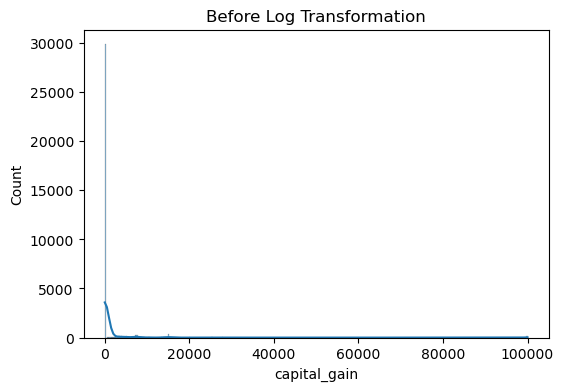

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))

sns.histplot(df['capital_gain'],kde=True)

plt.title("Before Log Transformation")

plt.show()

#  Log Transformation

In [55]:
df['capital_gain_log'] = np.log1p(df['capital_gain'])

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,capital_total,hours_per_age,capital_gain_log
0,39,7,77516,9,13,4,1,1,4,Male,2174,0,40,39,<=50K,2174,1.025641,7.684784
1,50,6,83311,9,13,2,4,0,4,Male,0,0,13,39,<=50K,0,0.260000,0.000000
2,38,4,215646,11,9,0,6,1,4,Male,0,0,40,39,<=50K,0,1.052632,0.000000
3,53,4,234721,1,7,2,6,0,2,Male,0,0,40,39,<=50K,0,0.754717,0.000000
4,28,4,338409,9,13,2,10,5,2,Female,0,0,40,5,<=50K,0,1.428571,0.000000


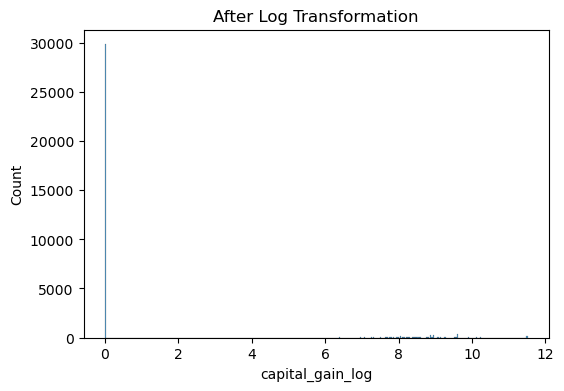

In [56]:
# Plot after transformation
plt.figure(figsize=(6,4))

sns.histplot(df['capital_gain_log'])

plt.title("After Log Transformation")

plt.show()

#  Correlation Heatmap

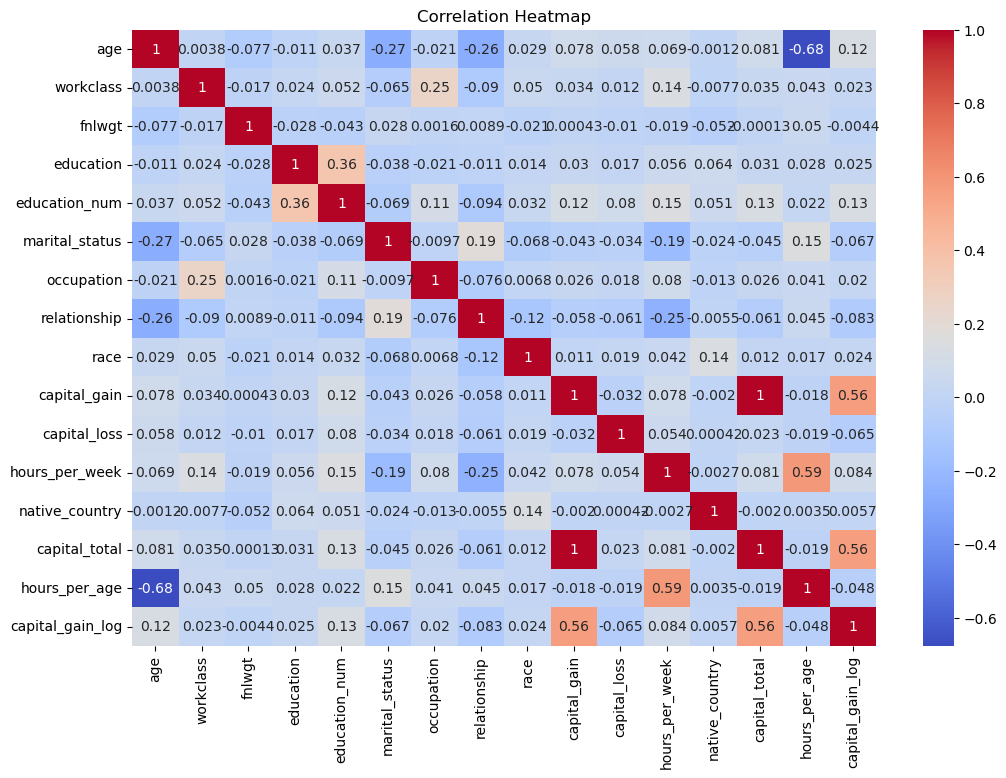

In [57]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


#  Conclusion:
-----------

In this assignment, various preprocessing and feature engineering techniques were successfully implemented on the Adult dataset.

The dataset was cleaned by handling missing values and applying scaling techniques such as Standard Scaling and Min-Max Scaling.

Categorical variables were encoded using One-Hot Encoding and Label Encoding. New meaningful features were created to improve predictive capability.

Log transformation was applied to reduce skewness in numerical data. Correlation analysis and visualizations helped better understand the dataset.

These preprocessing techniques improve data quality, model performance, and overall machine learning efficiency.